# ¡Hola Jose! ¿Cómo estás? 🙂
<div class="alert alert-block alert-info">
   
Mi nombre es <b>Andrés Barbosa</b> 👋 

Un gusto conocerte, seré tu revisor en este proyecto.
A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:
Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y
corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para
mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.
Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más
precisa, junto con algunos ejemplos prácticos. También estoy abierto a responder cualquier duda que
tengas.
Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
Puedes encontrar mis comentarios en cuadros verdes, amarillos o rojos como este:
</div>
<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. Todo se ha hecho de forma correcta.
</div>
<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. Algunas recomendaciones o mejoras menores.
</div>
<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita arreglos. Este apartado requiere algunas correcciones. El trabajo no puede ser aceptado
con comentarios rojos.
</div>
<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:
Respuesta del estudiante.
</div>

Empecemos! 🚀

<div class="alert alert-block alert-danger">
<b>Comentario general del revisor</b><br><br>¡Hola Jose! Entiendo lo que planteás sobre la capacidad de tu computadora, pero no hace falta que descargues ni almacenes el dataset completo. Las imágenes ya están en la plataforma de TripleTen, en la carpeta <code>/datasets/faces/</code>, así que podés hacer todo el proyecto directamente ahí, sin ocupar espacio en tu PC.<br><br>Tal como está, el notebook todavía no tiene nada resuelto: falta el análisis exploratorio con sus conclusiones, las cuatro funciones del modelo (siguen con el "# coloca tu código aquí") y el resultado del entrenamiento. Por eso no puedo aprobarlo todavía.<br><br>Te propongo esto: hacé el EDA directamente en la plataforma, donde ya tenés los datos disponibles. Después definís las cuatro funciones del modelo y el entrenamiento es opcional que sí se debería correr en la plataforma GPU (Google Colab por ejemplo) pero esa parte al ser opcional podés dejarla en blanco. Con eso el proyecto queda encaminado. ¡Quedo atento a tu reentrega!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general del revisor (iteración 2)</b><br><br>¡Hola de nuevo, Jose! Gracias por la reentrega, y bien por animarte a trabajar directamente en la plataforma. El análisis exploratorio quedó completo con una buena conclusión, y <code>create_model</code> y <code>train_model</code> están correctas.<br><br><b>Proyecto aprobado.</b><br><br>Te dejo igual algunas observaciones sobre las funciones de carga (<code>load_train</code> y <code>load_test</code>). Como el entrenamiento en la GPU es opcional, no bloquean la aprobación, pero si en algún momento querés correr el modelo vas a necesitar corregirlas. Te las detallo abajo. ¡Felicitaciones!
</div>

# Gracias 
Hola, agradezco la alcaracion respecto al almacenamiento del Dataset, pense que no podria hacer este proyecto.

Quedo atento a las revisiones

Saludos 😊

# HOLA, MI PC NO TIENE TANTA CAPACIDAD PARA ALMACENAR EL DATASET COMPLETO, POR ELLO NO PUEDO REALIZAR EL PROYECTO

## Inicialización




In [ ]:
import tensorflow as tf
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns

from PIL import Image
from matplotlib.image import imread
from glob import glob
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array


## Carga los datos

El conjunto de datos se almacena en la carpeta `/datasets/faces/` 
- La carpeta `final_files` con 7600 fotos 
- El archivo `labels.csv` con etiquetas, con dos columnas: `file_name` y `real_age` 
Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. Este método se explicó en el capítulo 3, lección 7 de este curso.

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [5]:
df_ages = pd.read_csv('/datasets/faces/labels.csv')

path = '/datasets/faces'
classes = sorted([d for d in os.listdir(path)
                  if os.path.isdir(os.path.join(path, d))])

image_paths = []
for ext in ("jpg", "jpeg", "png", "JPG", "JPEG", "PNG"):
    image_paths.extend(glob(os.path.join(path, "*", f"*.{ext}")))

df_image = pd.DataFrame({'image_path': image_paths})
df_image['label'] = df_image['image_path'].apply(lambda p: os.path.basename(os.path.dirname(p)))
print("Se ha creeado el dataframe con la informacion de las imagenes y sus etiquetas")
    
le = LabelEncoder()
df_image["label_id"] = le.fit_transform(df_image["label"])

train_df, test_df = train_test_split(df_image, test_size=0.2, stratify=df_image["label_id"], random_state=12345,)

def load_data(df_image, width, height, batch_size,  directory=None,):
    train_datagen = ImageDataGenerator(rescale=1./255)
    train_generator = train_datagen.flow_from_dataframe(
        df_image, 
        directory=directory,
        x_col='image_path',
        y_col='label',
        target_size=(width, height),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )
    
train = load_data(train_df, 225, 225, 16)
valid = load_data(test_df, 225, 225, 16)

Se ha creeado el dataframe con la informacion de las imagenes y sus etiquetas
Found 6072 validated image filenames belonging to 1 classes.
Found 1519 validated image filenames belonging to 1 classes.


## EDA

    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17
-------------------------
Estadisticas del DF
-------------------------
          real_age
count  7591.000000
mean     31.201159
std      17.145060
min       1.000000
25%      20.000000
50%      29.000000
75%      41.000000
max     100.000000


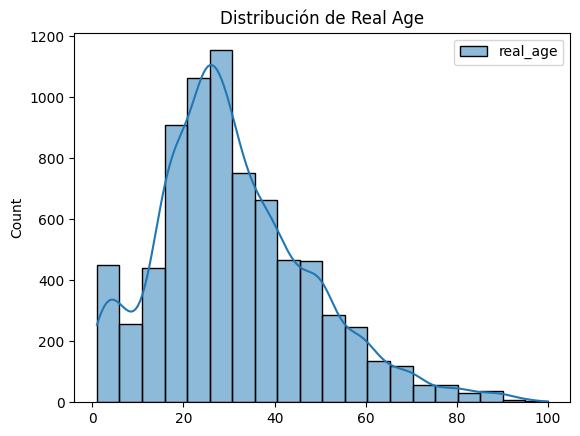

In [6]:
print(df_ages.head())
print('-'*25)
print('Estadisticas del DF')
print('-'*25)
print(df_ages.describe())

sns.histplot(data=df_ages, bins=20, kde=True)
plt.title('Distribución de Real Age')
plt.show()

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b><br><br>Acá va el análisis exploratorio, que por ahora está vacío. Podés hacerlo directamente en la plataforma sin descargar nada. Para el EDA no necesitás cargar las 7.600 fotos a la vez: te alcanza con leer <code>labels.csv</code> con pandas, graficar la distribución de la columna <code>real_age</code> (un histograma) y mostrar algunas imágenes de muestra para ver ángulos, calidad e iluminación. Cerrá con una breve conclusión sobre lo que observás, por ejemplo el desbalance de edades. Esa parte no requiere GPU.
</div>

/datasets/faces/final_files/002661.jpg


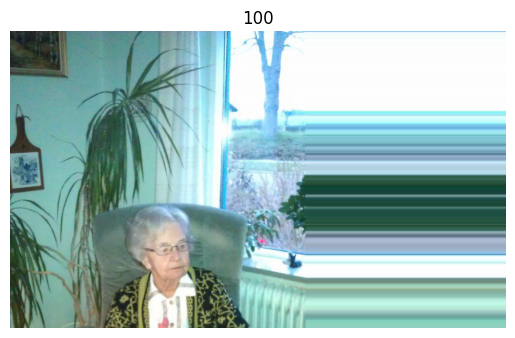

In [7]:
#Imprimir posibles outliers
age = 100

filtrado = df_ages[df_ages['real_age'] == age]['file_name'].tolist()
base_dir = '/datasets/faces/final_files'
for archivo in filtrado:
    ruta_img = os.path.join(base_dir, archivo)
    print(ruta_img)

    img = Image.open(ruta_img)
    plt.imshow(img)
    plt.axis('off')
    plt.title(age) 
    plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  7591 non-null   object
 1   label       7591 non-null   object
 2   label_id    7591 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 178.0+ KB


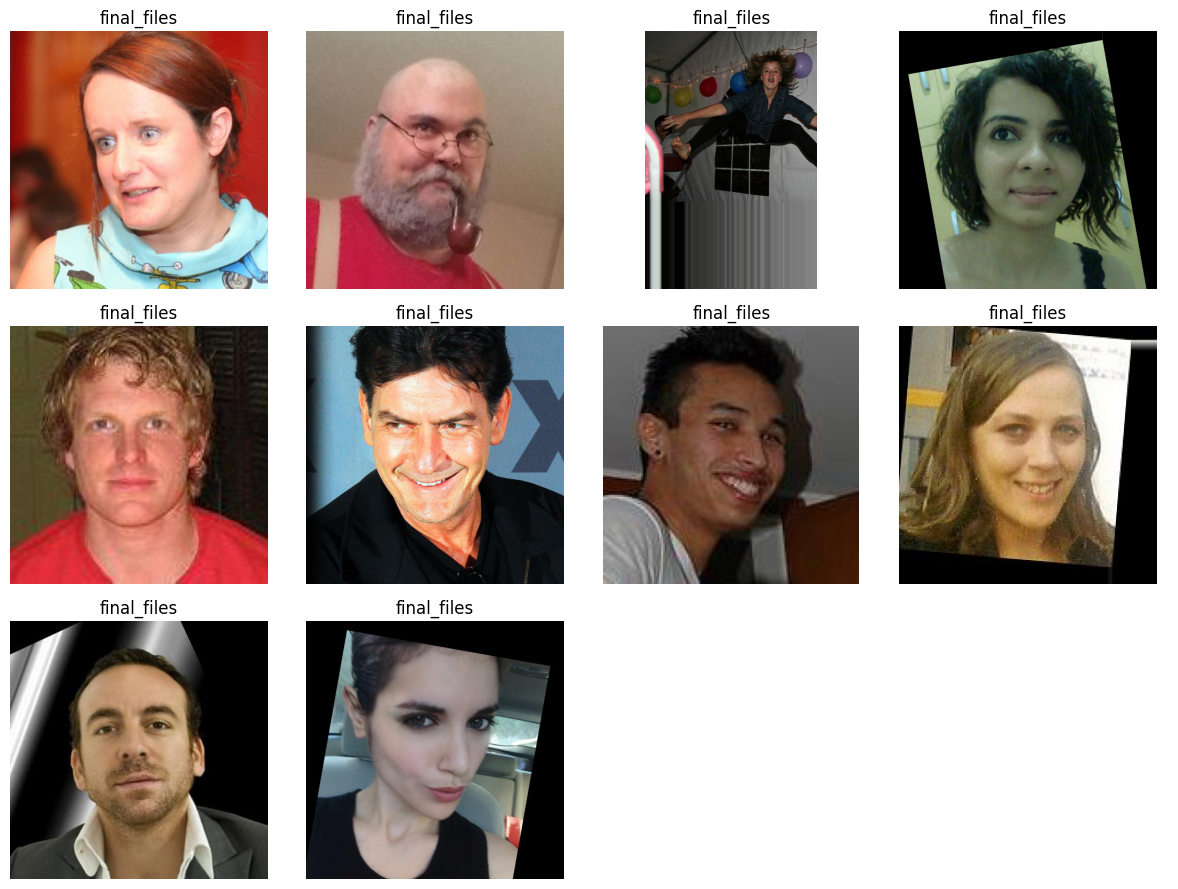

In [8]:
#Imprimimos ejemplos del dataset 
def plot_images(df, path_col="ruta", label_col="etiqueta", n=10, ncols=4):
    df = df.head(n)
    nrows = math.ceil(len(df) / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
    axes = axes.ravel()
    
    for i, (_, row) in enumerate(df.iterrows()):
        try:
            img = imread(row[path_col])
            axes[i].imshow(img)
            axes[i].set_title(row[label_col])
        except:
            axes[i].text(0.5, 0.5, "Error", ha="center")
        axes[i].axis("off")
    
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()

    
df_image.info()
plot_images(train_df, path_col='image_path', label_col='label')

### Conclusiones

In [ ]:
Se puede ver que el conjunto de los datos esta sesgado, la mayor parte de los datos se concentra entre los 20 y 40 años esto puede provocar que el modelo no prediga bien la edad pues tendrá pocos datos para aprender de las imagenes de personas de las edades de los extremos

<div class="alert alert-block alert-success">
<b>Comentario del revisor (iteración 2)</b><br><br>¡Resuelto! El EDA quedó completo y lo pudiste hacer en la plataforma sin problema: mostrás la distribución de edades, revisás los valores extremos, ponés ejemplos de las imágenes y cerrás con una buena conclusión sobre el sesgo del dataset hacia las edades de 20 a 40 años y su impacto en las predicciones de los extremos. Muy bien.
</div>

## Modelado

Define las funciones necesarias para entrenar tu modelo en la plataforma GPU y crea un solo script que las contenga todas junto con la sección de inicialización.

Para facilitar esta tarea, puedes definirlas en este notebook y ejecutar un código listo en la siguiente sección para componer automáticamente el script.

Los revisores del proyecto también verificarán las definiciones a continuación, para que puedan comprender cómo construiste el modelo.

In [ ]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [9]:
def load_train(df_image, width, height, batch_size,  directory=None,):
    
    train_datagen = ImageDataGenerator(rescale=1./255)
    train_gen_flow = train_datagen.flow_from_dataframe(
        df_image, 
        directory=directory,
        x_col='image_path',
        y_col='label',
        target_size=(width, height),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )
    
    return train_gen_flow

train = load_data(train_df, 225, 225, 16)

Found 6072 validated image filenames belonging to 1 classes.


In [10]:
def load_test(path):
    
    """
    Carga la parte de validación/prueba del conjunto de datos desde la ruta
    """
    
    # coloca tu código aquí

    return test_gen_flow

train = load_data(test_df, 225, 225, 16)

Found 1519 validated image filenames belonging to 1 classes.


In [11]:
def create_model(input_shape):
    
    """
    Define el modelo
    """
    backbone = ResNet50(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False,
    )
    
    
    model = Sequential(
        [
            backbone,
            GlobalAveragePooling2D(),
            Dense(1, activation='linear'),
        ]
    )
    
    optimizer = Adam(learning_rate=0.0001)
    

    model.compile(optimizer=optimizer, 
                                loss= 'mean_squared_error',
                  metrics=['mae'])

    return model


In [12]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Entrena el modelo dados los parámetros
    """
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data) 
        
    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2)

    return model

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b><br><br>Las cuatro funciones (<code>load_train</code>, <code>load_test</code>, <code>create_model</code> y <code>train_model</code>) siguen con el texto de la plantilla sin completar. Para la reentrega, definí cada una: los generadores con <code>ImageDataGenerator</code> (con <code>validation_split</code> y la misma semilla en train y test), el modelo con ResNet50 más <code>GlobalAveragePooling2D</code> y una capa <code>Dense</code> final, y acordate de compilar el modelo con una pérdida como <code>mean_squared_error</code> y la métrica <code>mae</code>. El entrenamiento en sí se ejecuta en la plataforma GPU.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (iteración 2)</b><br><br>Observaciones sobre las funciones de carga. No bloquean la aprobación, ya que el entrenamiento es opcional, pero conviene corregirlas si vas a correr el modelo. <code>create_model</code> y <code>train_model</code> quedaron bien (ResNet50 con la capa densa, compilado con MSE y MAE).<br><br>1) <code>load_test</code> todavía está sin completar, con el "# coloca tu código aquí" y devolviendo <code>test_gen_flow</code>, que no existe. Se define igual que <code>load_train</code> pero con <code>subset='validation'</code>.<br><br>2) En <code>load_train</code> hay tres cosas. Los nombres de columna deberían ser <code>file_name</code> y <code>real_age</code> (no <code>image_path</code> ni <code>label</code>). El <code>class_mode</code> debería ser <code>'raw'</code> en lugar de <code>'categorical'</code>, porque estás prediciendo un número. Y la última línea llama a <code>load_data(train_df, ...)</code>, que no existe. Para separar entrenamiento y validación desde el mismo <code>labels.csv</code>, sumá <code>validation_split</code> y la misma semilla en ambas funciones.
</div>

## Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, puedes redactar un script para la plataforma GPU, descargarlo a través del menú "File|Open..." (Archivo|Abrir) y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. A continuación se muestra un ejemplo.

In [ ]:
# prepara un script para ejecutarlo en la plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### El resultado

Coloca el resultado de la plataforma GPU como una celda Markdown aquí.

## Conclusiones

# Lista de control

- [ ]  El Notebook estaba abierto 
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución
- [ ]  Se realizó el análisis exploratorio de datos 
- [ ]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [ ]  El valor EAM del modelo no es superior a 8 
- [ ]  El código de entrenamiento del modelo se copió en el notebook final 
- [ ]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [ ] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo